# Demand Forecasting Analysis

## Objective
This notebook evaluates the performance of machine learning models used to forecast
shift-level nurse demand. Forecast accuracy is treated as diagnostic, not as the final goal.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
metrics = pd.read_csv("../results/forecast_metrics.csv")
metrics


,shift,model,MAE,RMSE
0,M,LinearRegression,1.285508,1.677904
1,M,RandomForest,1.376054,1.757751
2,E,LinearRegression,1.362699,1.737962
3,E,RandomForest,1.391991,1.784125
4,N,LinearRegression,0.995693,1.226445
5,N,RandomForest,0.999999,1.236101


**Observation**

- Linear Regression performs comparably to Random Forest across all shifts.
- This suggests demand patterns are largely linear and seasonal.


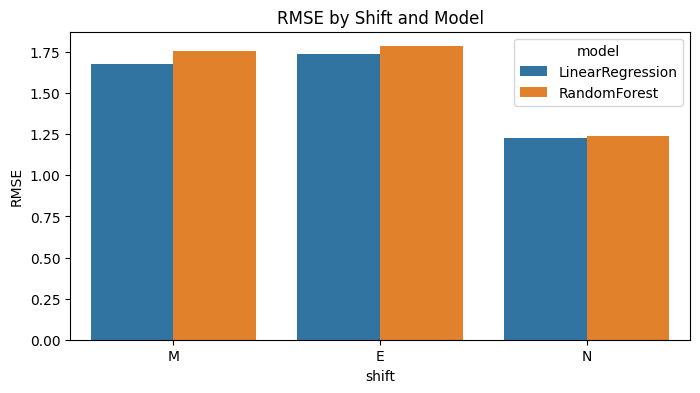

In [6]:
plt.figure(figsize=(8,4))
sns.barplot(data=metrics, x="shift", y="RMSE", hue="model")
plt.title("RMSE by Shift and Model")
plt.show()


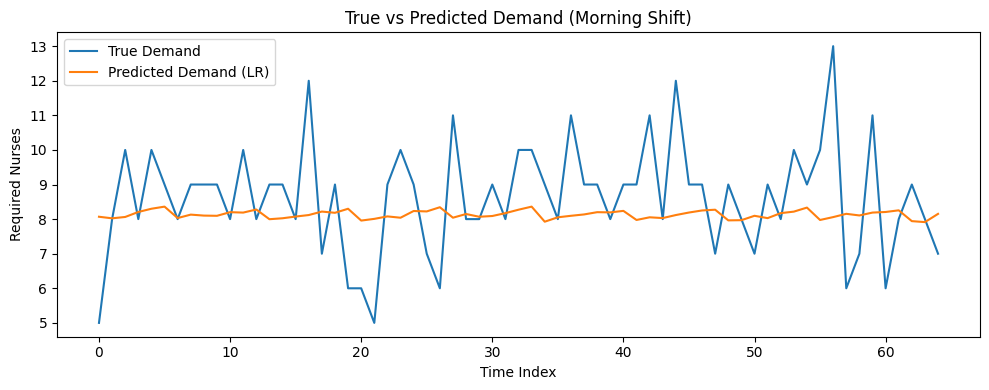

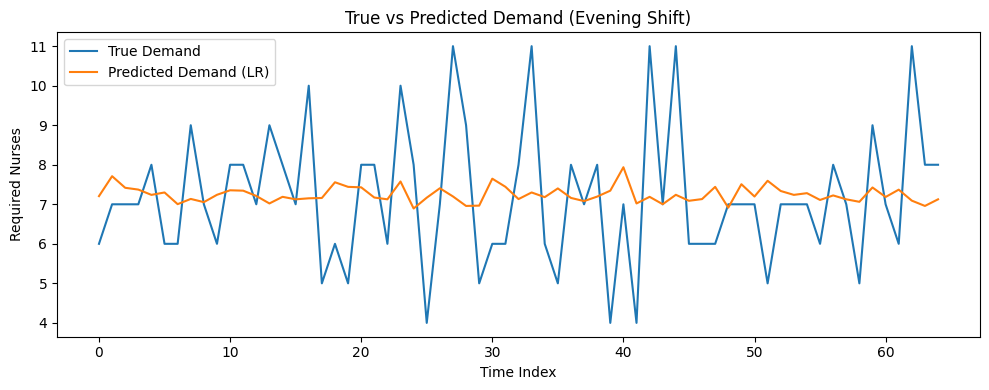

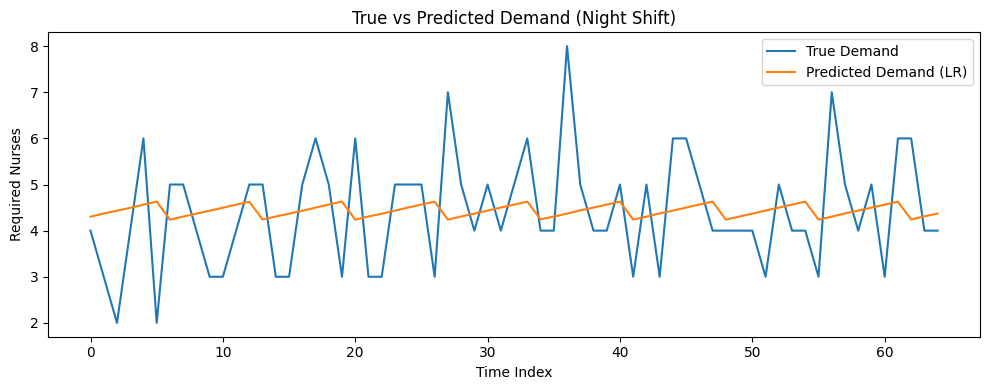

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

shifts = ["M", "E", "N"]
shift_names = {
    "M": "Morning",
    "E": "Evening",
    "N": "Night"
}

for shift in shifts:
    pred = pd.read_csv(
        f"../results/predictions/predictions_shift_{shift}.csv"
    )

    plt.figure(figsize=(10,4))
    plt.plot(pred["required_nurses"].values, label="True Demand")
    plt.plot(pred["pred_lr"].values, label="Predicted Demand (LR)")
    plt.legend()
    plt.title(f"True vs Predicted Demand ({shift_names[shift]} Shift)")
    plt.xlabel("Time Index")
    plt.ylabel("Required Nurses")
    plt.tight_layout()
    plt.show()



**Interpretation**

- Predictions track general demand trends but smooth sharp peaks.
- Extreme demand values are under-predicted.
- These errors are expected to influence staffing decisions.


**Key Takeaway**

While forecasting errors are moderate, prediction accuracy alone does not indicate
how these errors affect staffing decisions or costs.
